[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Optimizer077/jev-learning-course/blob/main/notebooks/01_jev_basics.ipynb)

# 1 · Jev: decisions your code can use

**Path:** Beginner  
**Before you start:** No machine learning background; basic Python only if you run cells

[Course home](../README.md) · [Course outline](../docs/COURSE.md) · [Setup help](../docs/SETUP.md) · [Glossary](../docs/GLOSSARY.md)

## The idea before the code

Imagine sorting support messages into queues. The model estimates which queue fits. Your program decides whether to use that estimate or ask for review.

**Your first pass:** Read sections 1–5 first. The later sections add useful distinctions, but you can return to them.

### Words you need for this lesson

| Word | Everyday meaning |
|---|---|
| **State** | The evidence you give the model. |
| **Criteria** | What each possible answer means. |
| **Distribution** | The probability assigned to every option. |
| **Policy** | Your program’s rule for choosing an action. |

### One message, three different questions

Our running message is **“The export button crashes. I cannot finish my report.”**
Changing the question changes what the answer should describe.

![Choice compares named queues; Score averages ordered levels; Noul estimates the positive answer to a yes/no question. All probabilities are authored illustrations.](../assets/question-types.svg)

| What do you need to know? | Type | How to read the result |
|---|---|---|
| Which queue best fits: technical, billing, or other? | **Choice** | A selected queue and probabilities over the queues |
| How much is work disrupted on a 0–2 rubric? | **Score** | An expected level on an ordered scale |
| Is a refund explicitly requested? | **Noul** | A probability for yes |

The question types are documented in the official [Choice](https://docs.typesafe.ai/primitives/choice),
[Score](https://docs.typesafe.ai/primitives/score), and [Noul](https://docs.typesafe.ai/primitives/noul) pages.
The probabilities shown later in this notebook are invented examples.

## Goal
Understand the interface before thinking about the neural network.
**Jev is a model from TypeSafe AI; “System One” is the company's name for its model class.**
It evaluates supplied context against bounded questions. It does not write a free-form reply.
[Official definition](https://docs.typesafe.ai/concepts/system-one).

Imagine a support inbox. A chatbot might write an explanation of where to send a ticket.
A decision interface gives your program an allowed queue and probabilities, so a normal
`if` statement can choose the next step.

All numbers below are **handmade illustrations**, not Jev outputs. Public documentation checked 2026-10-01.

## Setup
Run cells from top to bottom. No API key or model download is needed.

In [1]:
# Find the included teaching helpers from the course folder.
from pathlib import Path
import sys
REQUIRED_FILES = ("src/lab_core.py", "src/tutorial_utils.py", "data/tickets.json")
COURSE_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
                    if all((p / name).is_file() for name in REQUIRED_FILES)), None)
# Colab opens a single notebook; fetch its companion code and fictional data.
if COURSE_ROOT is None:
    try:
        import google.colab
    except ImportError:
        pass
    else:
        import subprocess
        COURSE_ROOT = Path("/content/jev-learning-course")
        if COURSE_ROOT.exists() and not all((COURSE_ROOT / name).is_file() for name in REQUIRED_FILES):
            raise FileNotFoundError("The cached Colab course is incomplete. Start a fresh runtime and run all again.")
        if not COURSE_ROOT.exists():
            subprocess.run(["git", "clone", "--depth", "1",
                            "https://github.com/Optimizer077/jev-learning-course.git",
                            str(COURSE_ROOT)], check=True)
if COURSE_ROOT is None:
    raise FileNotFoundError("Extract the complete course and open it from its folder.")
if str(COURSE_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(COURSE_ROOT / "src"))

import numpy as np
import matplotlib.pyplot as plt
from tutorial_utils import setup, show_figure, table, BLUE, ORANGE, GREY
setup()

## Steps
### 1. Separate state from the question
The **state** is the evidence. The **question** tells the model what judgment to make.
The **criteria** define the permitted answers and their meanings. First read this as: “How likely is each allowed answer, given the evidence and the question?” The formula below is optional. A useful abstract view is
$p_\theta(a\mid s,q,C)$: probabilities over answers $a$, given state $s$, question $q$,
and criteria $C$, using learned parameters $\theta$.

This notation describes the interface, not the implementation of Jev's neural network.

In [2]:
state = {'message': 'The export button crashes every time I click it.'}
question = {
    'type': 'choice',
    'instructions': 'Which support queue best matches the reported problem?',
    'criteria': {
        'billing': 'Charges, invoices, or refunds',
        'technical': 'Broken product behavior',
        'other': 'No listed queue fits or the information is insufficient',
    },
}
print('Evidence:', state['message'])
print('Question:', question['instructions'])
table(['Allowed key', 'Meaning'], question['criteria'].items())

Evidence: The export button crashes every time I click it.
Question: Which support queue best matches the reported problem?


Allowed key,Meaning
billing,"Charges, invoices, or refunds"
technical,Broken product behavior
other,No listed queue fits or the information is insufficient


### 2. Choice: pick from named alternatives
A Choice returns the highest-probability key and the distribution over the options.
Options are relative alternatives; include an escape option when none may fit.
[Choice reference](https://docs.typesafe.ai/primitives/choice).

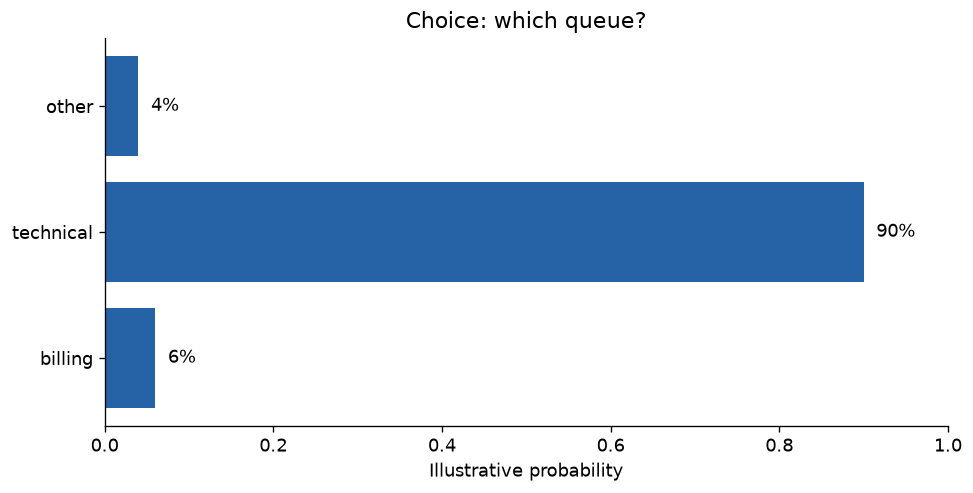

Selected key: technical


In [3]:
choice_probabilities = {'billing': 0.06, 'technical': 0.90, 'other': 0.04}
selected = max(choice_probabilities, key=choice_probabilities.get)
fig, ax = plt.subplots()
ax.barh(list(choice_probabilities), list(choice_probabilities.values()), color=BLUE)
ax.set(xlim=(0, 1), xlabel='Illustrative probability', title='Choice: which queue?')
for i, value in enumerate(choice_probabilities.values()):
    ax.text(value + 0.015, i, f'{value:.0%}', va='center')
show_figure('01_choice')
print('Selected key:', selected)

### 3. Score: an expectation over ordered levels
A Score uses an ordered list of descriptions. Indices start at 0.
With three levels the result is between 0 and 2, and can be fractional:
$$\text{score}=\sum_{k=0}^{K-1} k\,p(k).$$
This is a rubric position, not an exact measurement of an underlying physical quantity.
[Score reference](https://docs.typesafe.ai/primitives/score).

**In everyday words:** multiply each level by its probability, then add. A 70% chance of level 2 contributes 1.4 to the final score. You can follow the worked numbers without memorizing the formula.

In [4]:
levels = ['No disruption', 'Partial disruption', 'Work fully blocked']
probabilities = np.array([0.05, 0.25, 0.70])
score = np.dot(np.arange(len(levels)), probabilities)
table(['Level', 'Description', 'Probability'],
      [(i, label, f'{p:.0%}') for i, (label, p) in enumerate(zip(levels, probabilities))])
print(f'Score = {score:.2f} on a 0–2 scale')

# The same mean can conceal very different distributions.
print('Certain middle level:', np.dot([0, 1, 2], [0, 1, 0]))
print('Split across extremes:', np.dot([0, 1, 2], [0.5, 0, 0.5]))

Level,Description,Probability
0,No disruption,5%
1,Partial disruption,25%
2,Work fully blocked,70%


Score = 1.65 on a 0–2 scale
Certain middle level: 1
Split across extremes: 1.0


Both final examples give 1.0. Inspect the distribution when the difference matters.

### 4. Noul: a yes/no probability
A Noul returns a number from 0 to 1 representing the probability of “yes.” It is not
itself a Boolean; your code selects an action threshold.
[Noul reference](https://docs.typesafe.ai/primitives/noul).

In [5]:
# An invented answer to: "Does the message explicitly request a refund?"
noul = 0.12
threshold = 0.80  # Teaching policy, not a recommended production threshold.
print('Refund-request probability:', noul)
print('Meets our threshold:', noul >= threshold)

Refund-request probability: 0.12
Meets our threshold: False


### 5. Keep three ideas separate
**Probability** describes an outcome. The API's **confidence** summarizes distribution shape for
Choice and Score; Noul has no separate confidence field. **Calibration** describes agreement
between predicted probabilities and observed frequencies across many cases.
The confidence documentation does not specify its exact formula; do not substitute `max(p)`
and label it Jev confidence. [Confidence reference](https://docs.typesafe.ai/confidence).

### 6. Follow the full request through the system
This diagram is the **documented interface**, not a picture of proprietary layers.
The model estimates; the policy decides what happens. Notice that a confident topic prediction
does not by itself authorize sending a message, granting access, or changing a record.

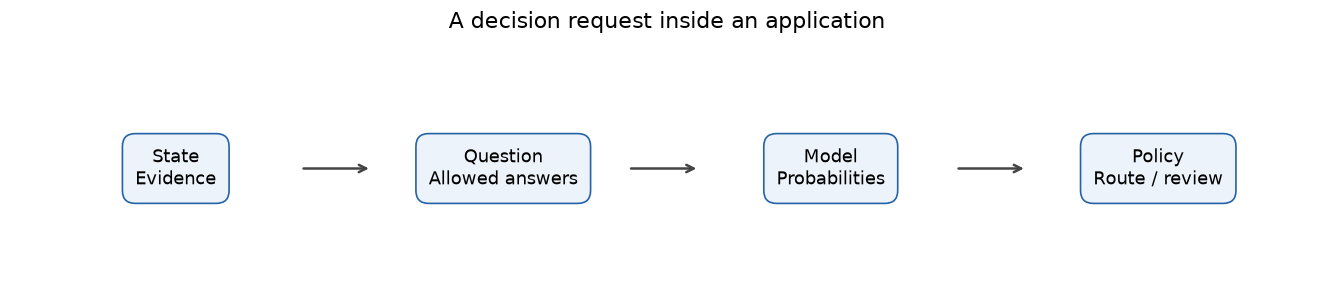

In [6]:
from tutorial_utils import flow_diagram
flow_diagram(['State\nEvidence', 'Question\nAllowed answers', 'Model\nProbabilities', 'Policy\nRoute / review'],
             '01_request_flow', 'A decision request inside an application')

### 7. Choice versus several Nouls
“Which topic is primary?” requires one winner; “Which topics are present?” may have several positives.
Choice probabilities share a denominator. Separate yes/no probabilities do not need to add to one.
The following handmade example mentions a broken export and a refund. It is perfectly reasonable
for both attributes to be present, even though only one queue must own the case.

In [7]:
multi_label = {'mentions_bug': 0.90, 'requests_refund': 0.85}
primary_topic = {'technical': 0.60, 'billing': 0.35, 'other': 0.05}
print('Sum of separate yes/no probabilities:', sum(multi_label.values()))
print('Sum over mutually exclusive primary topics:', sum(primary_topic.values()))
assert sum(multi_label.values()) > 1
assert np.isclose(sum(primary_topic.values()), 1)

Sum of separate yes/no probabilities: 1.75
Sum over mutually exclusive primary topics: 1.0


### 8. Known, claimed, and unknown

| Evidence level | What we can say | What we must not infer |
|---|---|---|
| Documented interface | State and typed questions produce bounded outputs | The answer is always true |
| Provider description | RLCD targets calibrated decisions; questions run in parallel | Calibration holds on every future dataset |
| Provider performance report | Published workflows show speed/cost advantages | The same ratio holds on your hardware and workload |
| Not disclosed in the reviewed pages | Exact weights, layer design, detailed RLCD objective and sampler | A softmax toy or attention mask reproduces Jev |

The final row matters: explaining a useful analogy is possible without inventing an architecture.
The [launch article](https://typesafe.ai/blog/introducing-system-one-models-and-jev) itself qualifies its benchmark claims.

**Predict first — exercise 1:** Which primitive fits each request?
1. Pick one support queue. 2. Is a refund explicitly requested? 3. Rate disruption against three ordered descriptions.
4. Write a reassuring email. Explain why the fourth needs a different kind of output.

### Your turn: change only the policy
Keep the same invented probabilities and try two thresholds. Predict the output before running.
This practice cell uses its own variables, so it does not change the earlier checks.

In [8]:
practice_probabilities = {'technical': 0.90, 'billing': 0.06, 'other': 0.04}
practice_queue = max(practice_probabilities, key=practice_probabilities.get)
for practice_threshold in [0.85, 0.95]:
    practice_action = practice_queue if practice_probabilities[practice_queue] >= practice_threshold else 'review'
    print(f'Threshold {practice_threshold:.2f}: {practice_action}')

Threshold 0.85: technical
Threshold 0.95: review


**Expected observation:** 0.85 routes to `technical`; 0.95 sends it to `review`. The estimated topic did not change.

## Checks
Type safety constrains answer shape. It does not prove that the chosen answer is true.

In [9]:
assert selected in question['criteria']
assert np.isclose(sum(choice_probabilities.values()), 1)
assert np.isclose(score, 1.65)
assert 0 <= noul <= 1

wrong_but_valid = 'billing'
assert wrong_but_valid in question['criteria']
print('"billing" passes the type check even though this ticket describes a product bug.')

"billing" passes the type check even though this ticket describes a product bug.


## Next Steps
Try moving 0.20 probability mass from “Work fully blocked” to “Partial disruption.”
Predict the new score before running the cell: it should decrease from 1.65 to 1.45.

Next: [build a tiny decision model](02_decision_model_from_scratch.ipynb) and see where probabilities can come from.

## Take three ideas with you

- Choice compares named options; Score averages ordered levels; Noul answers a yes/no question with a probability.
- The application owns the threshold and the action.
- Type safety prevents some format errors; it does not guarantee truth.

**You are ready to move on when:** You can explain Choice, Score, and Noul in your own words, and why a valid answer can still be wrong.

## Check your understanding

A model returns billing, one of the allowed options. Does that prove the ticket is about billing?

Pause and explain your answer before opening the explanation.

<details>
<summary>Show the explanation</summary>
<p>No. The value has the right shape, but the judgment can still be wrong. Output validity and accuracy answer different questions.</p>
</details>

For a short next step, try the [practice questions](../docs/PRACTICE.md).
For runnable exercises, use the [worked exercises](08_exercises_and_solutions.ipynb).

If you are unsure where to go next, use [the course outline](../docs/COURSE.md).

[Assignments](../assignments/README.md) · [Quick reference](../docs/QUICK_REFERENCE.md) · [Course outline](../docs/COURSE.md)